In [5]:
!pip install matplotlib seaborn -q

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from textwrap import wrap
import numpy as np
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook")
sns.set_palette("colorblind")


available_metrics = {
    "duration": "Benchmark Duration (s)",
    # "completed": "Completed Requests",
    # "request_throughput": "Request Throughput (req/s)",
    # "input_throughput": "Input Throughput (tokens/s)",
    # "output_throughput": "Output Throughput (tokens/s)",
    "mean_ttft_ms": "Mean TTFT (ms)",
    "median_ttft_ms": "Median TTFT (ms)",
    "std_ttft_ms": "Std Dev TTFT (ms)",
    "p99_ttft_ms": "P99 TTFT (ms)",
    "mean_tpot_ms": "Mean TPOT (ms)",
    "median_tpot_ms": "Median TPOT (ms)",
    "std_tpot_ms": "Std Dev TPOT (ms)",
    "p99_tpot_ms": "P99 TPOT (ms)",
    # "mean_itl_ms": "Mean ITL (ms)",
    # "median_itl_ms": "Median ITL (ms)",
    # "std_itl_ms": "Std Dev ITL (ms)",
    # "p99_itl_ms": "P99 ITL (ms)",
    # "mean_e2e_latency_ms": "Mean E2E Latency (ms)",
    # "median_e2e_latency_ms": "Median E2E Latency (ms)",
}

In [64]:
def plot_metric_by_strategy(file_name, metric):
    df = pd.read_csv(file_name)
    df = df[df['gpu_type'] != 'gpu_type']
    df[metric] = pd.to_numeric(df[metric], errors='raise')
    
    # Create a wider figure
    plt.figure(figsize=(12, 5))
    
    # Wrap long benchmark labels
    df['benchmark_label'] = df['benchmark_label'].str.replace("_", " ")
    df['wrapped_label'] = df['benchmark_label'].apply(lambda x: '\n'.join(wrap(x, 15)))
    
    # Define the order of strategies
    strategy_order = [
        'random',
        'round_robin',
        'pow_of_2',
        'prefix_aware'
    ]
    
    # Get the original order of labels
    original_label_order = df['wrapped_label'].unique()
    

    # Check if each strategy within the same benchmark label has the same number of results
    strategy_counts_by_label = df.groupby(['wrapped_label', 'scheduler_strategy']).size().reset_index(name='count')
    counts_per_label = strategy_counts_by_label.groupby('wrapped_label')['count'].nunique()
    
    if counts_per_label.nunique() == 1 and counts_per_label.iloc[0] == 1:
        # All labels have the same number of results per strategy
        num_seeds = strategy_counts_by_label['count'].iloc[0]
    else:
        # Inconsistent number of results across labels or strategies
        num_seeds = -1
    
    # Calculate mean and standard error for each group
    grouped = df.groupby(['wrapped_label', 'scheduler_strategy'])
    avg_df = grouped[metric].mean().reset_index()
    std_df = grouped[metric].std().reset_index()
    
    # Merge mean and std into a single dataframe
    avg_df = avg_df.merge(std_df, on=['wrapped_label', 'scheduler_strategy'], suffixes=('', '_std'))
    
    # Create the grouped bar chart with specified order and error bars
    ax = sns.barplot(x='wrapped_label', y=metric, hue='scheduler_strategy', 
                     hue_order=strategy_order, data=avg_df,
                     order=original_label_order)
    
    # # Add error bars manually
    # for i, p in enumerate(ax.patches):
    #     row_idx = i % len(avg_df)
    #     std_value = avg_df.iloc[row_idx][f'{metric}_std']
        
    #     # Only add error bars if std is not NaN (happens when only one sample)
    #     if not np.isnan(std_value) and num_seeds != -1:
    #         # Calculate standard error
    #         std_error = std_value / np.sqrt(num_seeds)
            
    #         # Add error bars
    #         ax.errorbar(p.get_x() + p.get_width() / 2., 
    #                    p.get_height(), 
    #                    yerr=std_error, 
    #                    fmt='none', 
    #                    color='black', 
    #                    capsize=3)
    
    # Add value labels on top of each bar
    for i, p in enumerate(ax.patches):
        value = p.get_height()
        text = f"{value:.1f}"
        ax.annotate(text, (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom')
    
    # Customize the plot
    if num_seeds != -1:
        plt.title(f"{available_metrics[metric]} by Routing Strategy (averaged over {num_seeds} seeds)")
    else:
        plt.title(f"{available_metrics[metric]} by Routing Strategy")
    plt.xlabel('Benchmark Label')
    plt.ylabel(available_metrics[metric])
    
    # Improve legend labels
    strategy_labels = {
        'random': 'Random',
        'round_robin': 'Round Robin',
        'pow_of_2': 'Power of 2',
        'prefix_aware': 'Prefix Aware',
    }
    handles, labels = ax.get_legend_handles_labels()
    # Place legend to the right of the plot
    ax.legend(handles, [strategy_labels[label] for label in labels], 
              title="Routing Strategy", 
              bbox_to_anchor=(1.05, 1), 
              loc='upper left')
    
    # Adjust layout to make sure everything fits
    plt.tight_layout()
    plt.show()

In [65]:
def plot_load_distribution(json_file_path, title=None):
    """
    Plot the load distribution over time for each replica on a single chart.
    
    Args:
        json_file_path: Path to the JSON file containing load distribution data
    """
    import json
    import matplotlib.pyplot as plt
    import numpy as np
    from matplotlib.ticker import MaxNLocator, MultipleLocator
    
    # Load the data from the JSON file
    with open(json_file_path, 'r') as f:
        load_data = json.load(f)
    
    # Convert the data to a more usable format
    times = sorted([float(t) for t in load_data.keys() if load_data[t]])
    replicas = list(load_data[str(times[0])].keys())
    
    # Create a single figure with smaller size
    plt.figure(figsize=(12, 4))
    
    # Define colors for each replica
    colors = ['blue', 'red', 'green', 'purple']
    
    # Store all replica loads to calculate average
    all_replica_loads = []
    
    # Plot each replica's load over time on the same chart
    for i, replica_id in enumerate(replicas):
        if i >= 4:  # Only plot the first 4 replicas
            break
            
        # Extract data for this replica
        replica_loads = [load_data[str(t)].get(replica_id, 0) for t in times]
        all_replica_loads.append(replica_loads)
        
        # Plot the data with different color for each replica (more transparent)
        # Using smaller marker size (markersize=4)
        plt.plot(times, replica_loads, marker='o', markersize=1, linestyle='-', linewidth=0.5, 
                 color=colors[i], label=f'Replica ID: {replica_id}', alpha=0.5)
    
    # Calculate and plot the average load
    avg_loads = None
    avg_load_value = 0
    if all_replica_loads:
        avg_loads = np.mean(all_replica_loads, axis=0)
        plt.plot(times, avg_loads, marker='s', markersize=2, linestyle='-', linewidth=2, 
                 color='black', label='Average Load', alpha=0.5, zorder=10)
        
        # Calculate average load during high-load period (when avg > 5)
        if any(load > 5 for load in avg_loads):
            start_idx = next((i for i, load in enumerate(avg_loads) if load > 5), 0)
            end_idx = len(avg_loads) - next((i for i, load in enumerate(reversed(avg_loads)) if load > 5), 0) - 1
            if start_idx <= end_idx:
                high_load_window = avg_loads[start_idx:end_idx+1]
                avg_load_value = np.mean(high_load_window) if high_load_window.size > 0 else 0
    
    # Set title with average load information
    if title is not None:
        plot_title = f'Load Distribution: {title}'
    else:
        plot_title = 'Load Distribution'
    
    if avg_loads is not None and avg_load_value > 0:
        plot_title += f' (Avg Load: {avg_load_value:.2f})'
    
    plt.title(plot_title)
    plt.xlabel('Time (seconds)')
    plt.ylabel('Number of Requests')
    plt.grid(True)
    # Place legend outside the plot to avoid overlapping with lines
    # plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # Set y-axis to integers from 0 to 20 inclusive
    ax = plt.gca()
    ax.set_ylim(0, 20)
    ax.yaxis.set_major_locator(MultipleLocator(1))
    
    # Make sure the ticks are visible
    ax.tick_params(axis='y', which='major', length=6)
    
    # Adjust layout to make room for the legend
    plt.tight_layout()
    plt.subplots_adjust(right=0.8)
    plt.show()

In [66]:
def plot_prefix_match_rate(json_file_path, title=None):
    """
    Plot the prefix match rates for each replica on a single chart.
    
    Args:
        json_file_path: Path to the JSON file containing prefix match rates data
        title: Optional title for the plot
    """
    import json
    import matplotlib.pyplot as plt
    import numpy as np
    import random
    from scipy.signal import savgol_filter
    
    # Load the data from the JSON file
    with open(json_file_path, 'r') as f:
        data = json.load(f)
    
    # Create a figure
    plt.figure(figsize=(12, 4))
    
    # Define colors for different replicas
    colors = ['blue', 'red', 'green', 'purple', 'orange', 'brown', 'pink', 'gray']
    
    # Store all match rates for calculating average
    all_match_rates = []
    max_length = 0
    
    # Plot each replica's match rates
    for i, (replica_id, match_rates) in enumerate(data.items()):
        # Create indices for x-axis (0 to len(match_rates)-1)
        indices = np.arange(len(match_rates))
        
        # Track the maximum length for average calculation
        max_length = max(max_length, len(match_rates))
        
        # Store match rates for average calculation
        all_match_rates.append(match_rates)
        
        # Apply jitter for zero values based on replica index
        jittered_match_rates = []
        for rate in match_rates:
            jittered_match_rates.append(rate + random.uniform(-0.02, 0.02))
            # if rate == 0:
            #     # Add jitter at y=0 based on replica index (0.1 * i)
            #     jittered_match_rates.append(0 + 0.02 * i)
            # else:
            #     jittered_match_rates.append(rate)
        
        # Calculate replica-specific statistics
        replica_avg_rate = np.mean(match_rates) if match_rates else 0
        replica_matches = sum(1 for rate in match_rates if rate > 0.1)
        replica_total = len(match_rates)
        replica_match_percentage = (replica_matches / replica_total * 100) if replica_total > 0 else 0
        
        # Plot the data points with enhanced legend
        plt.scatter(indices, jittered_match_rates, 
                   color=colors[i % len(colors)], 
                   alpha=0.5,
                   s=5,  # smaller point size
                   label=f'Replica ID: {replica_id}: Avg Hit Rate: {replica_avg_rate:.2f}, Matches: {replica_matches}/{replica_total} ({replica_match_percentage:.1f}%)')
    
    # Calculate the overall average hit rate across all data points
    all_rates = []
    for rates in all_match_rates:
        all_rates.extend(rates)
    overall_avg_rate = np.mean(all_rates) if all_rates else 0
    
    # Calculate the number of matches (match rate > 0.1)
    num_matches = sum(1 for rate in all_rates if rate > 0.1)
    total_requests = len(all_rates)
    match_percentage = (num_matches / total_requests * 100) if total_requests > 0 else 0
    
    # Calculate and plot the average hit rate
    if all_match_rates:
        # Pad shorter arrays with NaN to make them all the same length
        padded_rates = []
        for rates in all_match_rates:
            if len(rates) < max_length:
                padded = rates + [np.nan] * (max_length - len(rates))
                padded_rates.append(padded)
            else:
                padded_rates.append(rates)
        
        # Convert to numpy array and calculate average, ignoring NaN values
        avg_rates = np.nanmean(padded_rates, axis=0)
        
        # Smooth the average line using Savitzky-Golay filter
        # Only apply smoothing if we have enough data points
        if max_length > 10:
            window_length = min(max_length // 4 * 2 + 1, 51)  # Must be odd and less than data length
            window_length = max(5, window_length)  # At least 5
            polyorder = min(3, window_length - 1)  # Must be less than window_length
            
            # Replace NaN values with interpolated values for smoothing
            nan_indices = np.isnan(avg_rates)
            if np.any(nan_indices):
                x = np.arange(len(avg_rates))
                avg_rates_no_nan = avg_rates.copy()
                avg_rates_no_nan[nan_indices] = np.interp(
                    x[nan_indices], x[~nan_indices], avg_rates[~nan_indices]
                )
                smoothed_avg = savgol_filter(avg_rates_no_nan, window_length, polyorder)
            else:
                smoothed_avg = savgol_filter(avg_rates, window_length, polyorder)
            
            # Plot the smoothed average line with average hit rate in the legend
            plt.plot(np.arange(max_length), smoothed_avg, 
                     color='black', 
                     linewidth=2, 
                     label=f'Average Hit Rate: {overall_avg_rate:.2f}, Matches: {num_matches}/{total_requests} ({match_percentage:.1f}%)',
                     zorder=10)
        else:
            # If not enough data points for smoothing, plot the original average
            plt.plot(np.arange(max_length), avg_rates, 
                     color='black', 
                     linewidth=2, 
                     label=f'Average Hit Rate: {overall_avg_rate:.2f}, Matches: {num_matches}/{total_requests} ({match_percentage:.1f}%)',
                     zorder=10)
    
    # Set plot title and labels
    plt.title(f'Prefix Match Rates: {title}' if title else 'Prefix Match Rates')
    plt.xlabel('Index')
    plt.ylabel('Match Rate (0-1)')
    
    # Set y-axis limits
    plt.ylim(-0.05, 1.05)
    
    # Add grid
    plt.grid(True, alpha=0.3)
    
    # Add legend
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # Adjust layout
    plt.tight_layout()
    plt.subplots_adjust(right=0.8)
    
    plt.show()

In [67]:
def plot_all_load_distributions(load_dist_dir):
    """
    Plot load distributions for all JSON files in the specified directory.
    
    Args:
        load_dist_dir (str): Directory containing load distribution JSON files
    """
    import os
    import glob
    
    # Get all JSON files in the directory
    json_files = glob.glob(os.path.join(load_dist_dir, "*.json"))
    
    # Map of strategy prefixes to full strategy names
    strategy_names = {
        "random": "Random",
        "round": "Round Robin",
        "pow": "Power of 2",
        "prefix": "Prefix Aware"
    }
    
    # Extract the last part of the directory for the title
    dir_title = os.path.basename(os.path.normpath(load_dist_dir))
    # Create a dictionary to group files by strategy
    strategy_files = {}
    for file_path in json_files:
        filename = os.path.basename(file_path)
        strategy_prefix = filename.split('_')[0]  # Get the part before the first underscore
        
        if strategy_prefix not in strategy_files:
            strategy_files[strategy_prefix] = []
        
        strategy_files[strategy_prefix].append(file_path)
    # Sort each group of files
    for strategy in strategy_files:
        strategy_files[strategy] = sorted(strategy_files[strategy])
    # Process files in order of strategy_names, then by filename
    for strategy_prefix in ["random", "round", "pow", "prefix"]:
        if strategy_prefix in strategy_files:
            for file_path in strategy_files[strategy_prefix]:
                # Get the full strategy name or use the prefix if not found
                strategy_name = strategy_names.get(strategy_prefix, strategy_prefix.capitalize())
                # Plot the load distribution with directory title
                # plot_load_distribution(file_path, f"{strategy_name} - {dir_title}")
                plot_load_distribution(file_path, f"{strategy_name}")

In [68]:
def plot_all_prefix_match_rates(match_rates_dir):
    """
    Plot prefix match rates for all JSON files in the specified directory.
    
    Args:
        match_rates_dir (str): Directory containing prefix match rates JSON files
    """
    import os
    import glob
    
    # Get all JSON files in the directory
    json_files = glob.glob(os.path.join(match_rates_dir, "*.json"))
    
    # Map of strategy prefixes to full strategy names
    strategy_names = {
        "random": "Random",
        "round": "Round Robin",
        "pow": "Power of 2",
        "prefix": "Prefix Aware"
    }
    
    # Extract the last part of the directory for the title
    dir_title = os.path.basename(os.path.normpath(match_rates_dir))
    
    # Create a dictionary to group files by strategy
    strategy_files = {}
    for file_path in json_files:
        filename = os.path.basename(file_path)
        strategy_prefix = filename.split('_')[0]  # Get the part before the first underscore
        
        if strategy_prefix not in strategy_files:
            strategy_files[strategy_prefix] = []
        
        strategy_files[strategy_prefix].append(file_path)
    
    # Sort each group of files
    for strategy in strategy_files:
        strategy_files[strategy] = sorted(strategy_files[strategy])
    
    # Process files in order of strategy_names, then by filename
    for strategy_prefix in ["random", "round", "pow", "prefix"]:
        if strategy_prefix in strategy_files:
            for file_path in strategy_files[strategy_prefix]:
                # Get the full strategy name or use the prefix if not found
                strategy_name = strategy_names.get(strategy_prefix, strategy_prefix.capitalize())
                
                # Plot the prefix match rates with directory title
                plot_prefix_match_rate(file_path, f"{strategy_name} - {dir_title}")


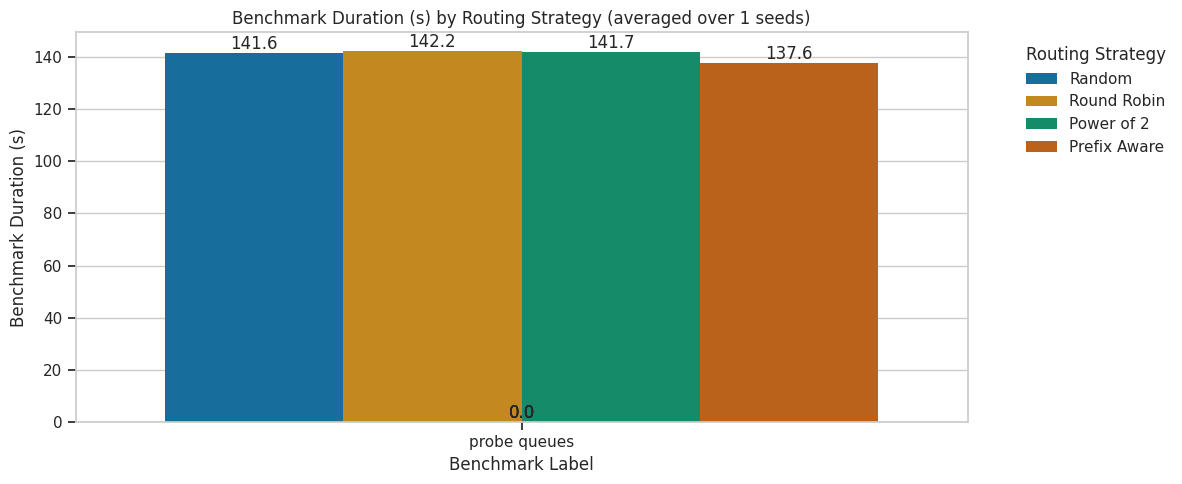

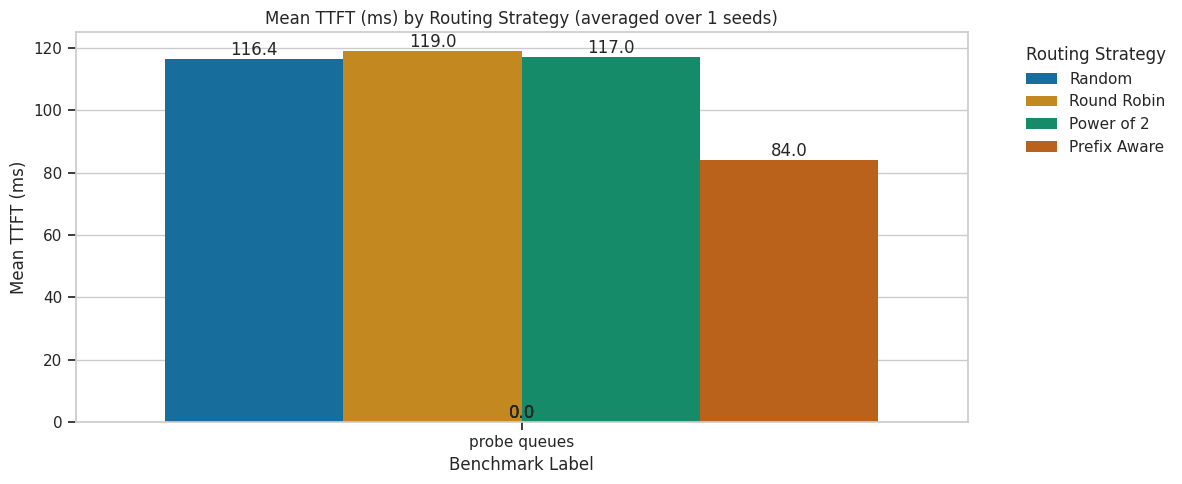

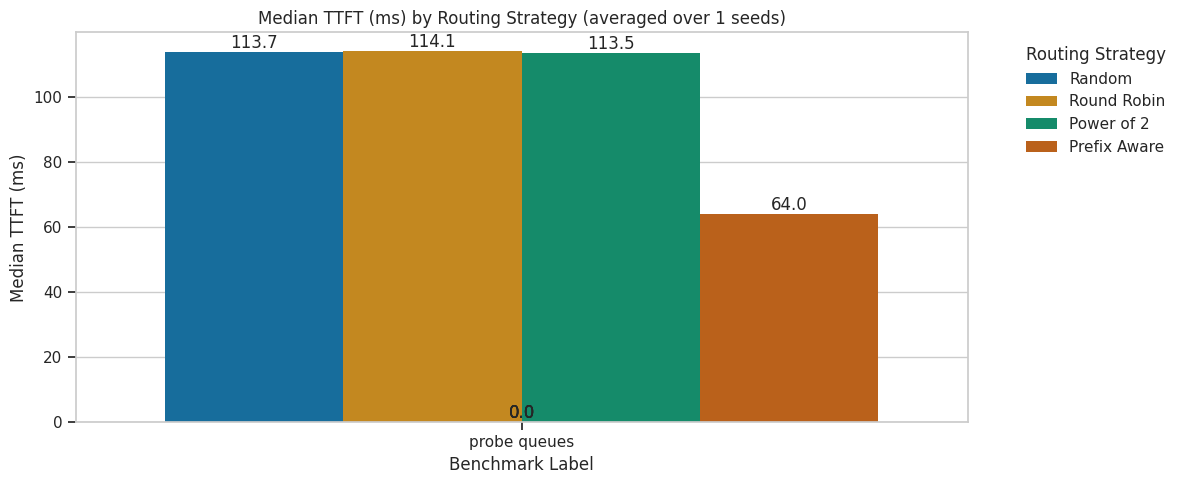

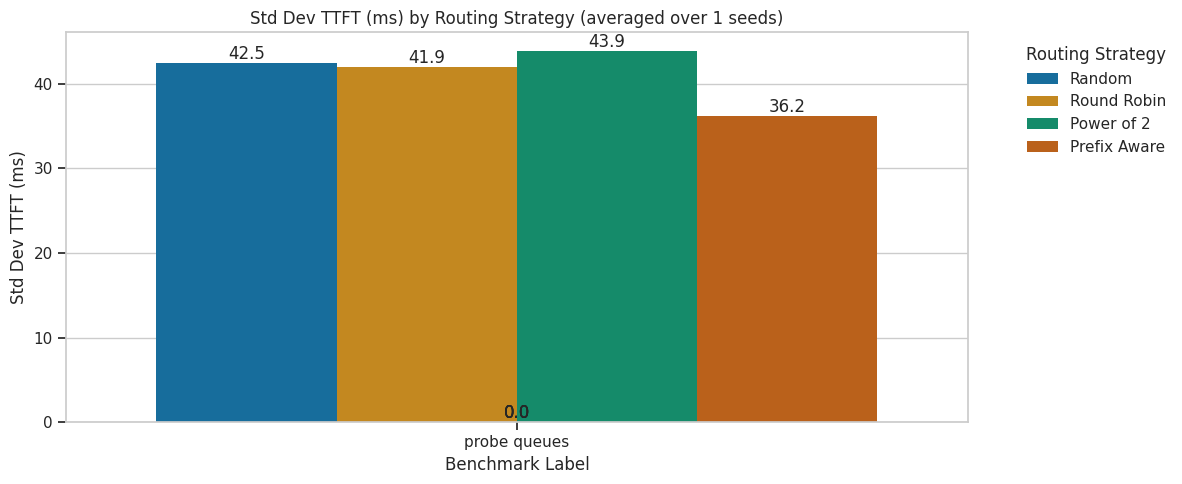

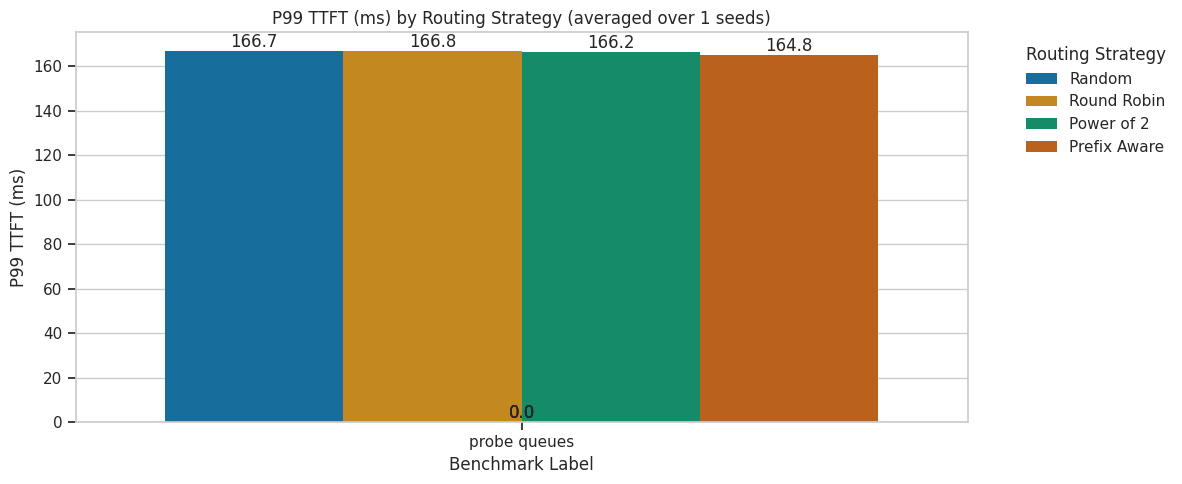

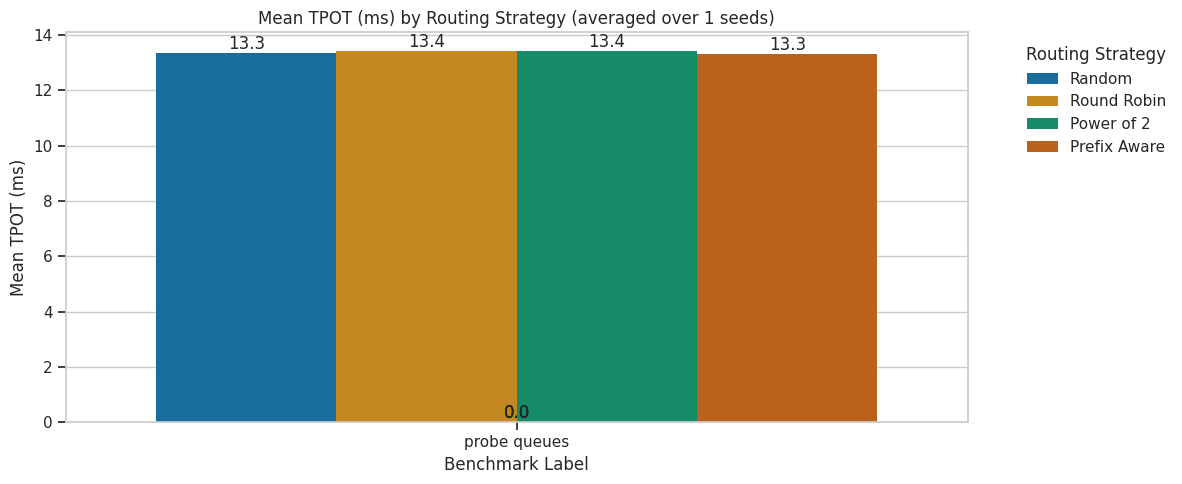

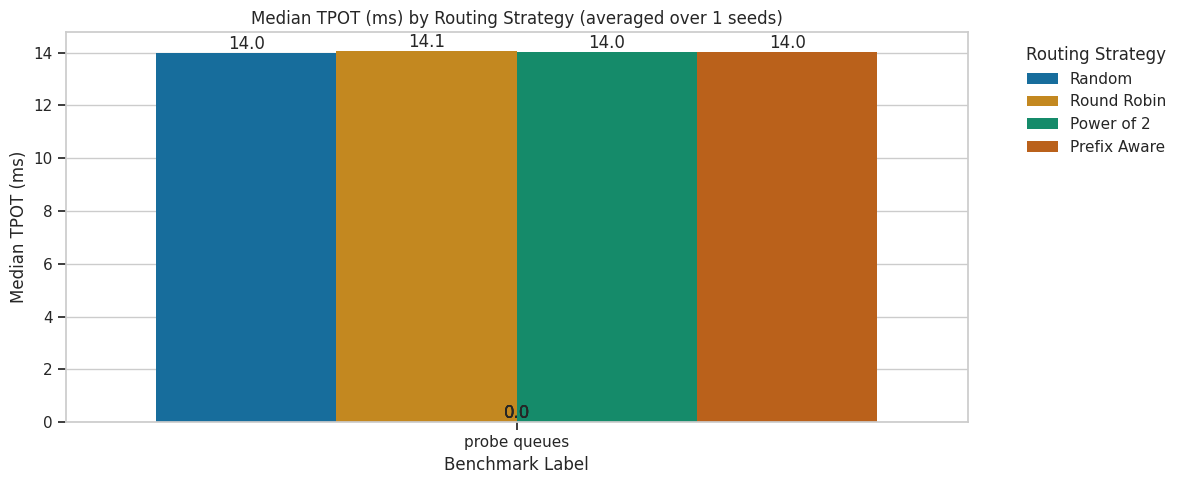

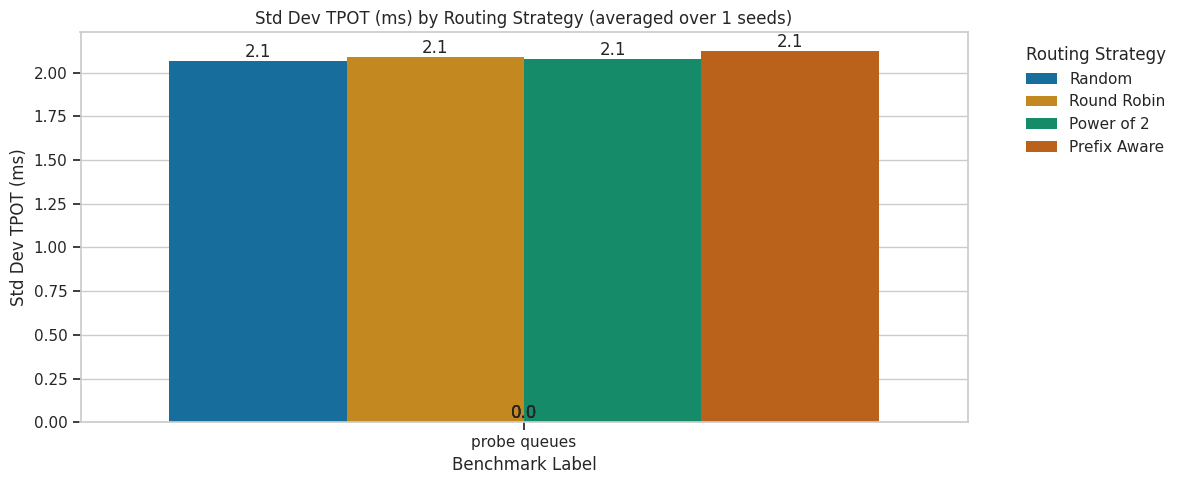

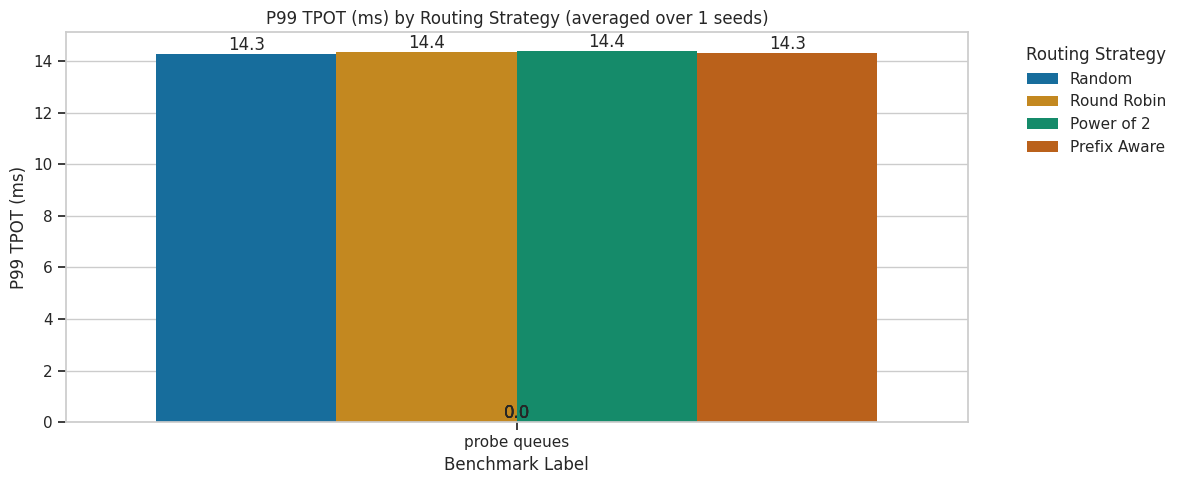

In [81]:
for metric in available_metrics:
    plot_metric_by_strategy("/home/ray/default/work/ray/_prefix_aware_playground/inside_ray/results/chosen_sweep_results.csv", metric)

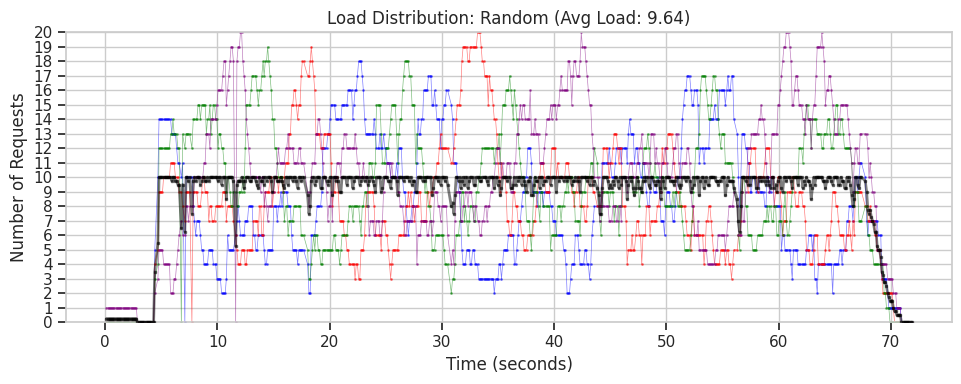

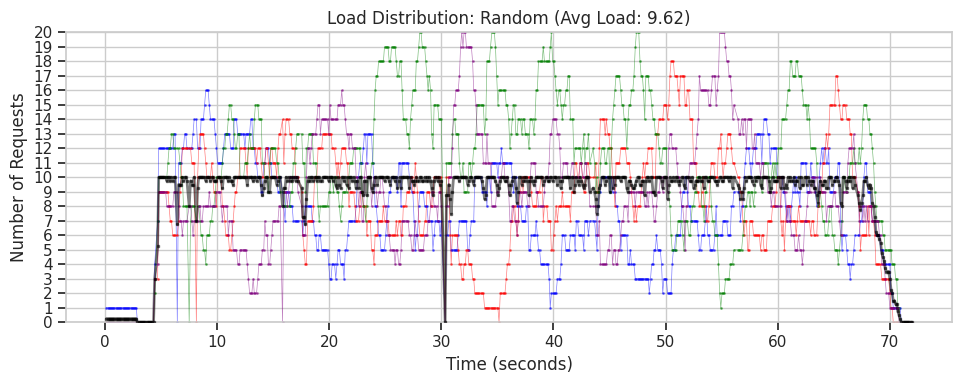

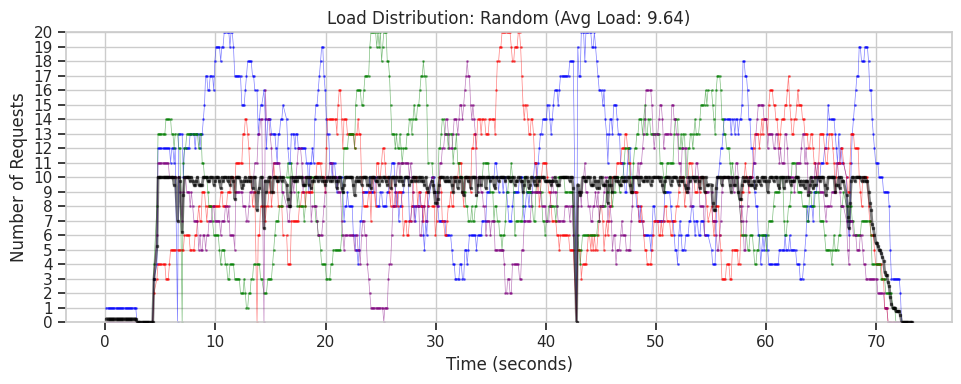

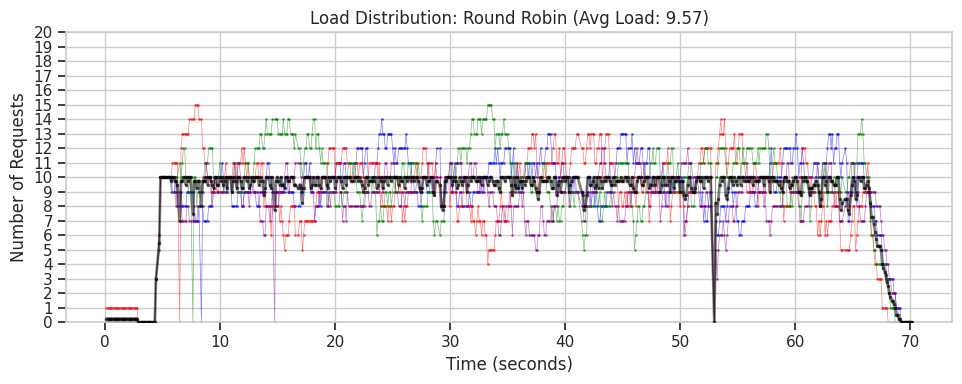

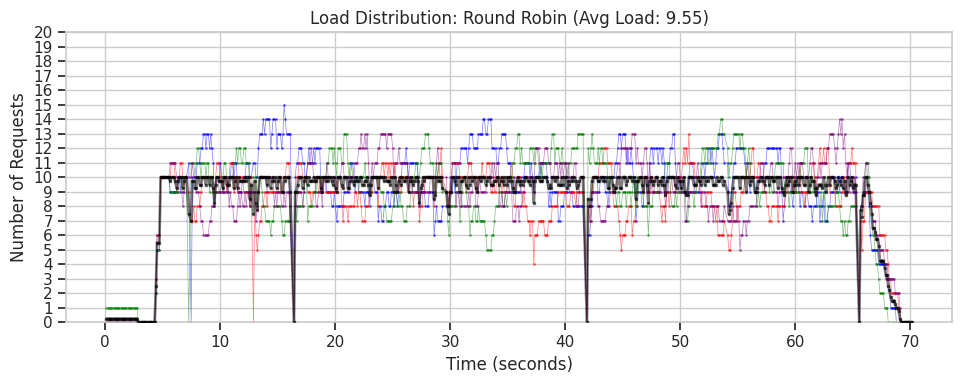

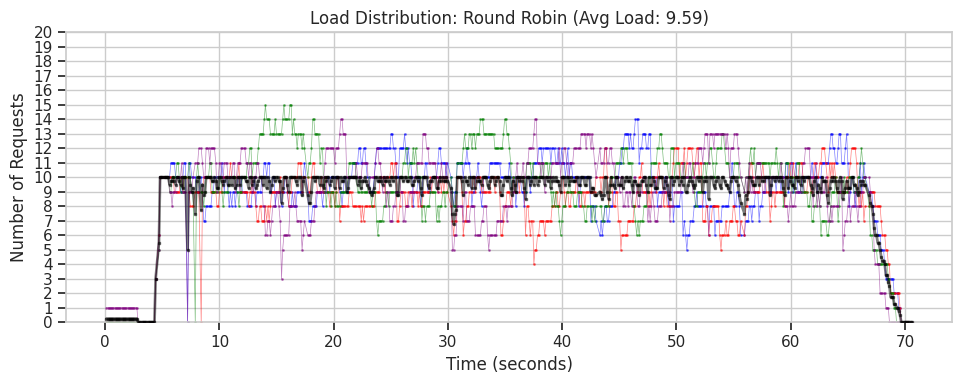

In [53]:
plot_all_load_distributions("/home/ray/default/work/ray/_prefix_aware_playground/inside_ray/results/load_distributions/no_overhead")

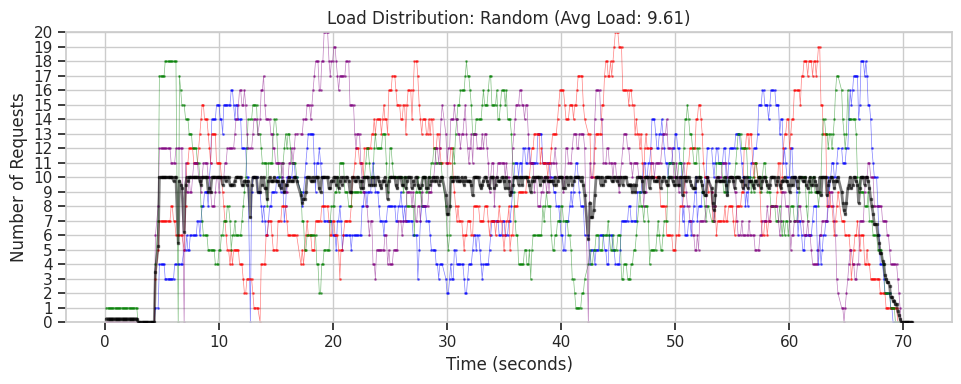

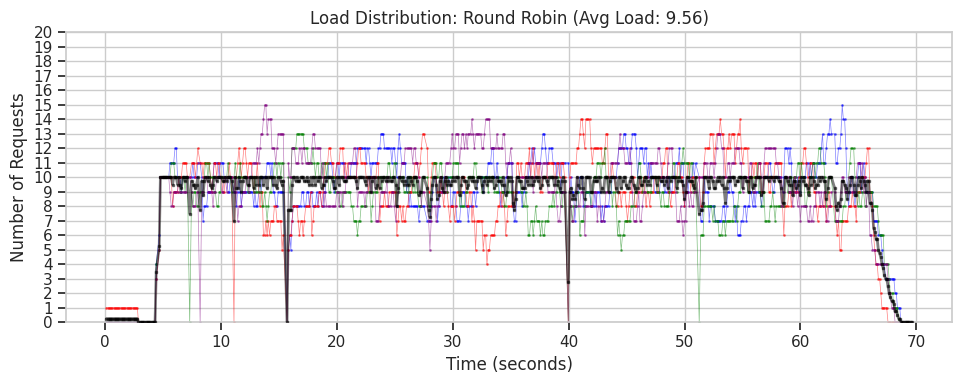

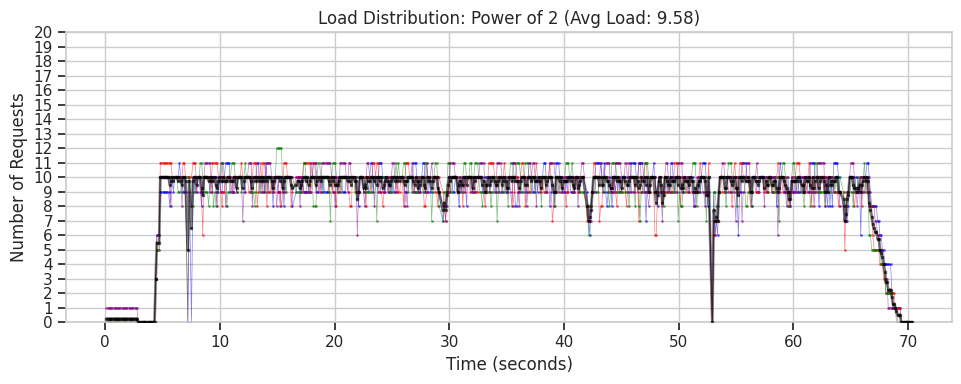

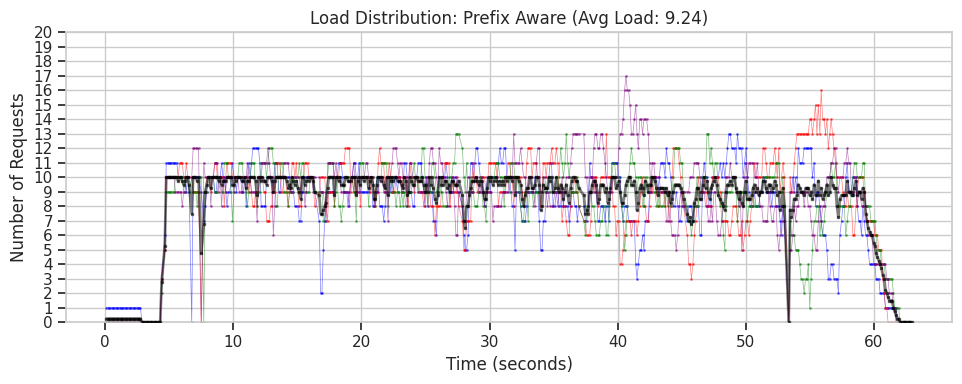

In [54]:
plot_all_load_distributions("/home/ray/default/work/ray/_prefix_aware_playground/inside_ray/results/load_distributions/hardcode_tree_and_probe_queues")